<a href="https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html">Tutorial Link</a>

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torchvision.transforms.v2 import functional as F
from torchvision import tv_tensors
from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes

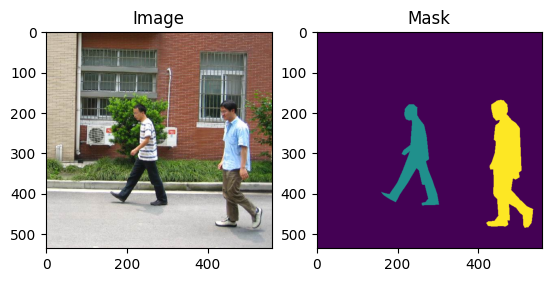

In [2]:
#example sample
mask = read_image('data/PennFudanPed/PedMasks/FudanPed00001_mask.png')
image = read_image('data/PennFudanPed/PNGImages/FudanPed00001.png')
fig, ax = plt.subplots(1,2)
ax[0].set_title('Image')
ax[0].imshow(image.permute(1,2,0))
ax[1].set_title('Mask')
ax[1].imshow(mask.permute(1,2,0))
plt.show()

In [36]:
class PennFudanDataset(Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(os.path.join(root, 'PNGImages'))))
        self.masks = list(sorted(os.listdir(os.path.join(root, 'PedMasks'))))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, 'PNGImages', self.imgs[idx])
        mask_path = os.path.join(self.root, 'PedMasks', self.masks[idx])
        img = read_image(img_path)
        mask = read_image(mask_path)
        #finding the classes from mask
        obj_ids = torch.unique(mask)
        #excluding the background class
        obj_ids = obj_ids[1:]
        num_objs = len(obj_ids)

        masks = ( mask == obj_ids[:, None, None]).to(dtype=torch.uint8)

        #get bounding box coordinates for each mask
        boxes = masks_to_boxes(masks)
        labels = torch.ones((num_objs, ), dtype=torch.int64)
        image_id = idx
        area = (boxes[:,3] - boxes[:,1]) * (boxes[:,2] - boxes[:,0])
        iscrowd = torch.zeros((num_objs, ), dtype=torch.int64)
        ing = tv_tensors.Image(img)

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
        target["masks"] = tv_tensors.Mask(masks)
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

In [21]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

In [22]:
def get_model_instance_segmentation(num_classes):
    #load an instance segmentation model
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    #get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model

In [23]:
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py")

--2026-04-05 21:23:13--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8000::154, 2606:50c0:8001::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4063 (4.0K) [text/plain]
Saving to: ‘engine.py’

     0K ...                                                   100% 68.0M=0s

2026-04-05 21:23:14 (68.0 MB/s) - ‘engine.py’ saved [4063/4063]

--2026-04-05 21:23:14--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8002::154, 2606:50c0:8000::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length

0

In [32]:
from torchvision.transforms import v2 as T


def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

In [37]:
import utils

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
dataset = PennFudanDataset('data/PennFudanPed', get_transform(train=True))
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=utils.collate_fn
)

# For Training
images, targets = next(iter(data_loader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output = model(images, targets)  # Returns losses and detections
print(output)

# For inference
model.eval()
x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
predictions = model(x)  # Returns predictions
print(predictions[0])

{'loss_classifier': tensor(0.1628, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0536, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0411, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0032, grad_fn=<DivBackward0>)}
{'boxes': tensor([], size=(0, 4), grad_fn=<StackBackward0>), 'labels': tensor([], dtype=torch.int64), 'scores': tensor([], grad_fn=<IndexBackward0>)}


In [45]:
from engine import train_one_epoch, evaluate

# train on the accelerator or on the CPU, if an accelerator is not available
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device('cpu')

# our dataset has two classes only - background and person
num_classes = 2
# use our dataset and defined transformations
dataset = PennFudanDataset('data/PennFudanPed', get_transform(train=True))
dataset_test = PennFudanDataset('data/PennFudanPed', get_transform(train=False))

# split the dataset in train and test set
indices = torch.randperm(len(dataset)).tolist()
dataset = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    collate_fn=utils.collate_fn
)

# get the model using our helper function
model = get_model_instance_segmentation(num_classes)

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

# let's train it just for 2 epochs
num_epochs = 2

for epoch in range(num_epochs):
    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    evaluate(model, data_loader_test, device=device)

print("That's it!")

Epoch: [0]  [ 0/60]  eta: 0:00:25  lr: 0.000090  loss: 3.9079 (3.9079)  loss_classifier: 0.4659 (0.4659)  loss_box_reg: 0.4440 (0.4440)  loss_mask: 2.9821 (2.9821)  loss_objectness: 0.0109 (0.0109)  loss_rpn_box_reg: 0.0050 (0.0050)  time: 0.4205  data: 0.0178  max mem: 4427
Epoch: [0]  [10/60]  eta: 0:00:17  lr: 0.000936  loss: 1.5403 (2.2455)  loss_classifier: 0.3826 (0.3460)  loss_box_reg: 0.3018 (0.3038)  loss_mask: 0.9481 (1.5737)  loss_objectness: 0.0120 (0.0164)  loss_rpn_box_reg: 0.0048 (0.0057)  time: 0.3457  data: 0.0171  max mem: 4671
Epoch: [0]  [20/60]  eta: 0:00:13  lr: 0.001783  loss: 0.8627 (1.4989)  loss_classifier: 0.2108 (0.2513)  loss_box_reg: 0.2563 (0.2689)  loss_mask: 0.4123 (0.9552)  loss_objectness: 0.0170 (0.0178)  loss_rpn_box_reg: 0.0042 (0.0056)  time: 0.3369  data: 0.0175  max mem: 4671
Epoch: [0]  [30/60]  eta: 0:00:10  lr: 0.002629  loss: 0.6224 (1.2075)  loss_classifier: 0.1139 (0.2059)  loss_box_reg: 0.2533 (0.2666)  loss_mask: 0.2218 (0.7117)  loss_ob

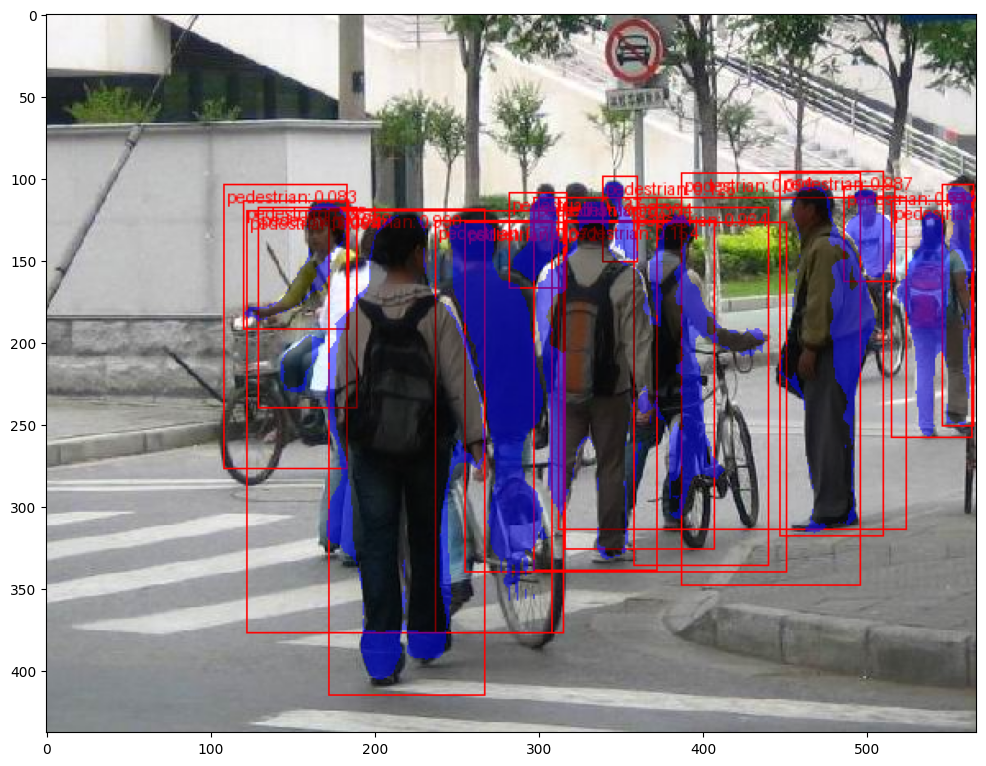

In [46]:
import matplotlib.pyplot as plt

from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks


image = read_image("data/PennFudanPed/PNGImages/FudanPed00046.png")
eval_transform = get_transform(train=False)

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]


image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]
pred_labels = [f"pedestrian: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")


plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))